In [1]:
# Exercise: ex18_logistic_regression

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = load_breast_cancer()

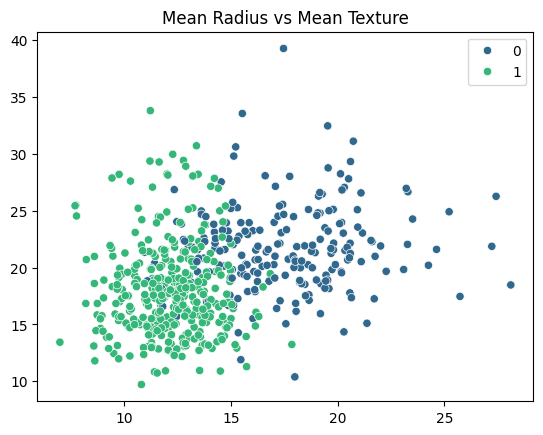

In [6]:
# b) Scatter Plot (First 2 features)
sns.scatterplot(x=data.data[:, 0], y=data.data[:, 1], hue=data.target, palette='viridis')
plt.title("Mean Radius vs Mean Texture")
plt.show()

In [8]:
# c) Split (70/30 Stratified)
X_train, X_test, y_train, y_test = train_test_split(data.data, data.target, test_size=0.3, stratify=data.target, random_state=42)

In [10]:
# d) Train Model
clf = LogisticRegression(max_iter=3000)
clf.fit(X_train, y_train)
print(f"Accuracy: {clf.score(X_test, y_test):.4f}")

Accuracy: 0.9474


In [11]:
# e) Metrics
y_pred = clf.predict(X_test)
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.89      0.93        64
           1       0.94      0.98      0.96       107

    accuracy                           0.95       171
   macro avg       0.95      0.94      0.94       171
weighted avg       0.95      0.95      0.95       171



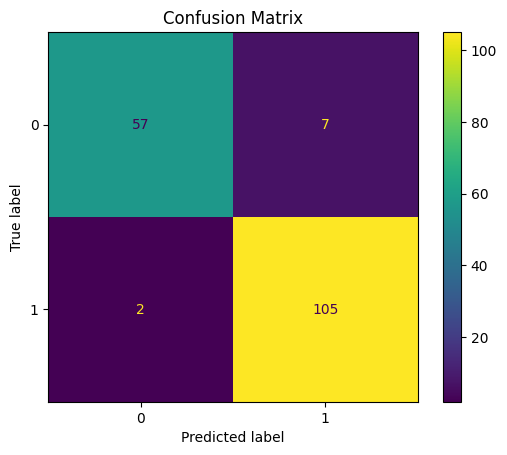

In [12]:
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Confusion Matrix")
plt.show()

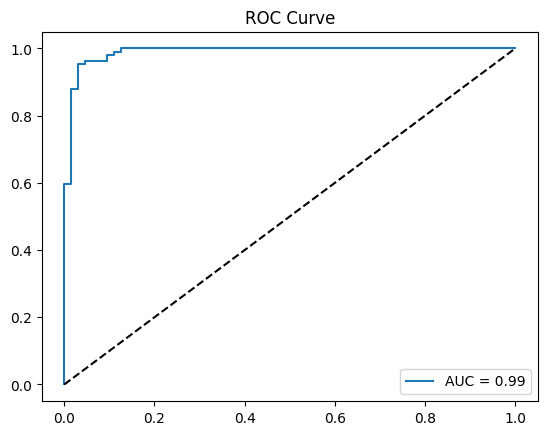

In [13]:
# ROC Curve
fpr, tpr, _ = roc_curve(y_test, clf.predict_proba(X_test)[:, 1])
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc(fpr, tpr):.2f}')
plt.plot([0, 1], [0, 1], 'k--')
plt.title("ROC Curve")
plt.legend()
plt.show()

In [14]:
# f) Prediction Probabilities
prob = clf.predict_proba(X_test[0].reshape(1, -1))
print(f"Prediction Probabilities (Class 0, Class 1): {prob[0]}")

Prediction Probabilities (Class 0, Class 1): [0.86717293 0.13282707]
